In [5]:
#HIDDEN WORKFORCE GROUP DISCOVERY USING CENSUS DATA
import pandas as pd
df=pd.read_csv("/content/adult_dataset.csv")
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [6]:
#checking the data duplicates
df.duplicated().sum()

np.int64(16)

In [7]:
df.drop_duplicates(inplace=True) #remove duplicates
#checking the data duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# check null value
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [9]:
from sklearn.impute import SimpleImputer
num_col = df.select_dtypes(include=['number']).columns
cat_col = df.select_dtypes(exclude=["number"]).columns
cat_col

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [10]:
#replace null with mean for numerical columns
num_imputer = SimpleImputer(strategy="mean")
df[num_col] = num_imputer.fit_transform(df[num_col])
df.isnull().sum()


,0
age,0
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [11]:
#replace null with most frequent for text/date columns
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_col] = cat_imputer.fit_transform(df[cat_col])
df.isnull().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
#find categories in income field
df['income'].value_counts()

,count
income,
<=50K,24709
<=50K.,12430
>50K,7841
>50K.,3846


In [13]:
#replace below 50K slab by 1 and abvoe 50K slab by 2
df['income'] = df['income'].replace({'<=50K': 1, '<=50K.': 1, '>50K': 2, '>50K.': 2})

/tmp/ipython-input-540829170.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'<=50K': 1, '<=50K.': 1, '>50K': 2, '>50K.': 2})


In [14]:
# find values after encoding
df['income'].value_counts()

,count
income,
1,37139
2,11687


In [15]:
# Apply onehot encoding for minimal categories
# onehot encoding - sex
df_encoded = pd.get_dummies(df, columns=['sex'],dtype=int,drop_first=True)

In [16]:
# Apply Label encoding since there multiple values in the below feature cloumns
# label encode - workclass, education, marital-status, occupation, relationship, race, native-country
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded['workclass']= le.fit_transform(df_encoded['workclass'])

In [17]:
df_encoded['education']= le.fit_transform(df_encoded['education'])
df_encoded['marital-status']= le.fit_transform(df_encoded['marital-status'])
df_encoded['occupation']= le.fit_transform(df_encoded['occupation'])

df_encoded['relationship']= le.fit_transform(df_encoded['relationship'])
df_encoded['race']= le.fit_transform(df['race'])
df_encoded['native-country']= le.fit_transform(df_encoded['native-country'])

In [18]:
df_encoded.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,hours-per-week,native-country,income,sex_Male
0,39.0,7,77516.0,9,13.0,4,1,1,4,2174.0,0.0,40.0,39,1,1
1,50.0,6,83311.0,9,13.0,2,4,0,4,0.0,0.0,13.0,39,1,1
2,38.0,4,215646.0,11,9.0,0,6,1,4,0.0,0.0,40.0,39,1,1
3,53.0,4,234721.0,1,7.0,2,6,0,2,0.0,0.0,40.0,39,1,1
4,28.0,4,338409.0,9,13.0,2,10,5,2,0.0,0.0,40.0,5,1,0


In [19]:
# apply scaling for numerical coulmns
# age, fnlwgt, house-per-week
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
#Apply Standard scaling to transform data
scaler = StandardScaler()

df_encoded[num_col] = scaler.fit_transform(df_encoded[num_col])

In [20]:
df_encoded.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,hours-per-week,native-country,income,sex_Male
0,0.023421,7,-1.061960,9,1.136533,4,1,1,4,0.146861,-0.217164,-0.036594,39,1,1
1,0.832389,6,-1.007084,9,1.136533,2,4,0,4,-0.144828,-0.217164,-2.227170,39,1,1
2,-0.050121,4,0.246072,11,-0.419444,0,6,1,4,-0.144828,-0.217164,-0.036594,39,1,1
3,1.053017,4,0.426704,1,-1.197432,2,6,0,2,-0.144828,-0.217164,-0.036594,39,1,1
4,-0.785547,4,1.408585,9,1.136533,2,10,5,2,-0.144828,-0.217164,-0.036594,5,1,0


In [21]:
#drop Column income
#df_encoded = df_encoded.drop("income", axis=1)

<Axes: xlabel='age', ylabel='hours-per-week'>

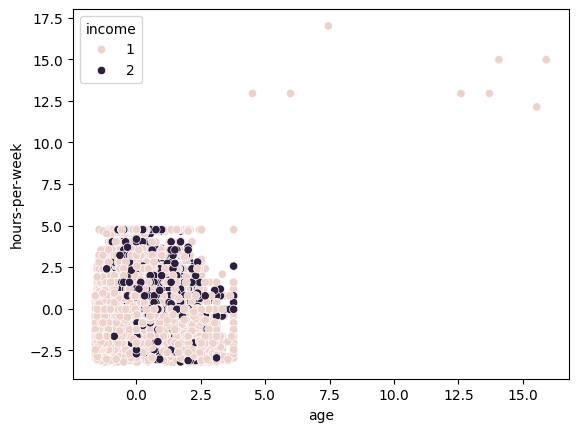

In [22]:
import seaborn as sns
sns.scatterplot(x="age",y="hours-per-week",data=df_encoded,hue="income")

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,init='k-means++',n_init=15,max_iter=250)  # Example with 3 clusters
df_encoded['Cluster'] = kmeans.fit_predict(scaled_features)
df_encoded

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,hours-per-week,native-country,income,sex_Male,Cluster
0,0.023421,7,-1.061960,9,1.136533,4,1,1,4,0.146861,-0.217164,-0.036594,39,1,1,2
1,0.832389,6,-1.007084,9,1.136533,2,4,0,4,-0.144828,-0.217164,-2.227170,39,1,1,2
2,-0.050121,4,0.246072,11,-0.419444,0,6,1,4,-0.144828,-0.217164,-0.036594,39,1,1,2
3,1.053017,4,0.426704,1,-1.197432,2,6,0,2,-0.144828,-0.217164,-0.036594,39,1,1,2
4,-0.785547,4,1.408585,9,1.136533,2,10,5,2,-0.144828,-0.217164,-0.036594,5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.023421,4,0.243922,9,1.136533,0,10,1,4,-0.144828,-0.217164,-0.361124,39,1,0,2
48838,1.861984,4,1.247546,11,-0.419444,6,10,2,2,-0.144828,-0.217164,-0.036594,39,1,1,0
48839,-0.050121,4,1.754925,9,1.136533,2,10,0,4,-0.144828,-0.217164,0.774730,39,1,1,2
48840,0.391134,4,-1.001592,9,1.136533,0,1,3,1,0.587079,-0.217164,-0.036594,39,1,1,2


In [24]:
#Evaluate Clustering
# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = kmeans.labels_
silhouette_avg = silhouette_score(scaled_features, labels)

print(silhouette_avg) #0.631640138719835

0.13914896595333007


In [25]:
# cluster summary
cluster_summary = df_encoded.groupby("Cluster").agg({
    "age": ["mean"],
    "workclass": ["mean"],
    "fnlwgt": ["mean"],
    "education": ["mean"],
    "marital-status": ["mean"],
    "occupation": ["mean"],
    "relationship": ["mean"],
    "hours-per-week": ["mean"],
    "race": ["mean"],
    "capital-gain": ["mean"],
    "capital-loss": ["mean"],
    "native-country": ["mean"],
    "sex_Male": ["mean"]
})
cluster_summary

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,hours-per-week,race,capital-gain,capital-loss,native-country,sex_Male
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Cluster,,,,,,,,,,,,,
0,-0.428805,3.771002,0.037591,10.157356,3.459012,6.566222,2.748858,-0.373819,3.524381,-0.107692,-0.214048,36.909489,0.352724
1,0.229239,4.007168,-0.012978,10.612903,2.385305,7.254032,1.011201,0.220396,3.739695,-0.144828,4.498134,37.108423,0.768369
2,0.352512,4.101457,-0.031540,10.373681,1.908255,7.233335,0.346310,0.305468,3.786531,0.106662,-0.216716,37.194726,0.934302


<Axes: xlabel='age', ylabel='hours-per-week'>

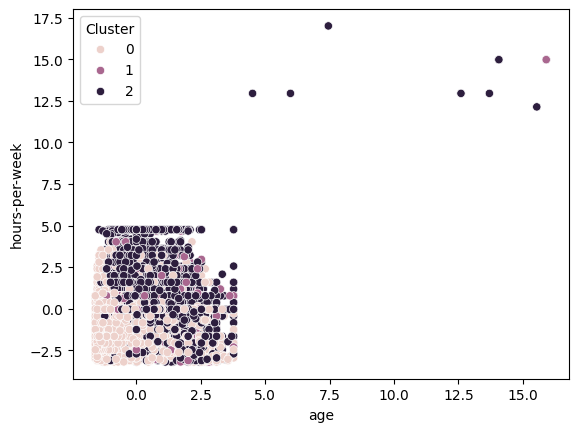

In [26]:
import seaborn as sns
sns.scatterplot(x="age",y="hours-per-week",hue="Cluster",data=df_encoded)

In [27]:
scaled_features

array([[ 0.02342123,  2.30446403, -1.06196015, ...,  0.27233101,
        -0.56096584,  0.70416531],
       [ 0.83238906,  1.54879397, -1.00708397, ...,  0.27233101,
        -0.56096584,  0.70416531],
       [-0.0501213 ,  0.03745385,  0.24607193, ...,  0.27233101,
        -0.56096584,  0.70416531],
       ...,
       [-0.0501213 ,  0.03745385,  1.75492524, ...,  0.27233101,
        -0.56096584,  0.70416531],
       [ 0.39113388,  0.03745385, -1.00159162, ...,  0.27233101,
        -0.56096584,  0.70416531],
       [-0.27074889,  0.79312391, -0.07113982, ...,  0.27233101,
         1.78263973,  0.70416531]])

In [28]:
from sklearn.cluster import KMeans, AgglomerativeClustering #hirearchy
 #bottom up technique
# Example with 3 clusters
hc = AgglomerativeClustering(n_clusters=3, linkage='single') # 'single' 'complete' 'average' 'ward'

# Fit and predict clusters
df_encoded['Cluster'] = hc.fit_predict(scaled_features)

df_encoded.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,hours-per-week,native-country,income,sex_Male,Cluster
0,0.023421,7,-1.061960,9,1.136533,4,1,1,4,0.146861,-0.217164,-0.036594,39,1,1,2
1,0.832389,6,-1.007084,9,1.136533,2,4,0,4,-0.144828,-0.217164,-2.227170,39,1,1,2
2,-0.050121,4,0.246072,11,-0.419444,0,6,1,4,-0.144828,-0.217164,-0.036594,39,1,1,2
3,1.053017,4,0.426704,1,-1.197432,2,6,0,2,-0.144828,-0.217164,-0.036594,39,1,1,2
4,-0.785547,4,1.408585,9,1.136533,2,10,5,2,-0.144828,-0.217164,-0.036594,5,1,0,2


In [30]:
# DBSCAN
from sklearn.cluster import DBSCAN

df = DBSCAN(eps=0.7 ,min_samples=100)  # eps may need tuning, snowball
labels = df_encoded.fit_predict(scaled_features) #pca(pc1, pc2)

# Add labels to DataFrame
df['cluster'] = labels


AttributeError: 'DataFrame' object has no attribute 'fit_predict'